# Regularizations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Set a random seed for reproducibility
np.random.seed(1836)

In [2]:
# --- Generate Synthetic Data ---
n_samples = 25
X = np.sort(np.random.uniform(0, 10, size=(n_samples, 1)), axis=0)
y = X.ravel() ** 2 + 10 * np.cos(X.ravel()) + np.random.normal(0, 5, n_samples)

X_plot = np.linspace(0, 10, 100).reshape(-1, 1)

In [3]:
# Split into training and validation sets (70% train, 30% validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)
# Polynomial degree
degree = 9

In [4]:
# Model 1: No Regularization
poly_no_reg = PolynomialFeatures(degree)
X_poly_no_reg = poly_no_reg.fit_transform(X_train)
model_no_reg = LinearRegression()
model_no_reg.fit(X_poly_no_reg, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [5]:
# Model 2: L1 Regularization (Lasso)
poly_l1 = PolynomialFeatures(degree)
X_poly_l1 = poly_l1.fit_transform(X_train)
model_l1 = Lasso(alpha=20, max_iter=10000)
model_l1.fit(X_poly_l1, y_train)

/home/shankubag04/.local/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.408e+02, tolerance: 1.498e+00
  model = cd_fast.enet_coordinate_descent(


,alpha,20
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,10000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [6]:
# Model 3: L2 Regularization (Ridge)
poly_l2 = PolynomialFeatures(degree)
X_poly_l2 = poly_l2.fit_transform(X_train)
model_l2 = Ridge(alpha=1000000)
model_l2.fit(X_poly_l2, y_train)

,alpha,1000000
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [7]:
# Predictions on full X_plot for visualization of the predicted curves
X_plot_poly_no_reg = poly_no_reg.transform(X_plot)
y_pred_no_reg = model_no_reg.predict(X_plot_poly_no_reg)

X_plot_poly_l1 = poly_l1.transform(X_plot)
y_pred_l1 = model_l1.predict(X_plot_poly_l1)

X_plot_poly_l2 = poly_l2.transform(X_plot)
y_pred_l2 = model_l2.predict(X_plot_poly_l2)

In [8]:
# To compute the validation error, you must predict on the validation set (X_val).
# First, transform X_val using the transformers that were ALREADY fitted on the training data.
# IMPORTANT: Use .transform(), not .fit_transform(), on the validation data.

# --- Predictions for Validation MSE ---
X_val_poly_no_reg = poly_no_reg.transform(X_val)
y_val_pred_no_reg = model_no_reg.predict(X_val_poly_no_reg)

X_val_poly_l1 = poly_l1.transform(X_val)
y_val_pred_l1 = model_l1.predict(X_val_poly_l1)

X_val_poly_l2 = poly_l2.transform(X_val)
y_val_pred_l2 = model_l2.predict(X_val_poly_l2)

In [9]:
# Compute validation error and see if you can minimise the MSE by
# changing the hyperparameter lambda (alpha in the above code) don't change
# any other parameters including the datapoints and degree of the polynomial.
mses = [
    mean_squared_error(y_val, y_val_pred_no_reg),
    mean_squared_error(y_val, y_val_pred_l1),
    mean_squared_error(y_val, y_val_pred_l2),
]
print("MSE on validation (no regulization): ", mses[0])
print("MSE on validation (L1 regulization): ", mses[1])
print("MSE on validation (L2 regulization): ", mses[2])
# ============================================================================

MSE on validation (no regulization):  165943.76790632805
MSE on validation (L1 regulization):  28.590165067988043
MSE on validation (L2 regulization):  25.598355453809567


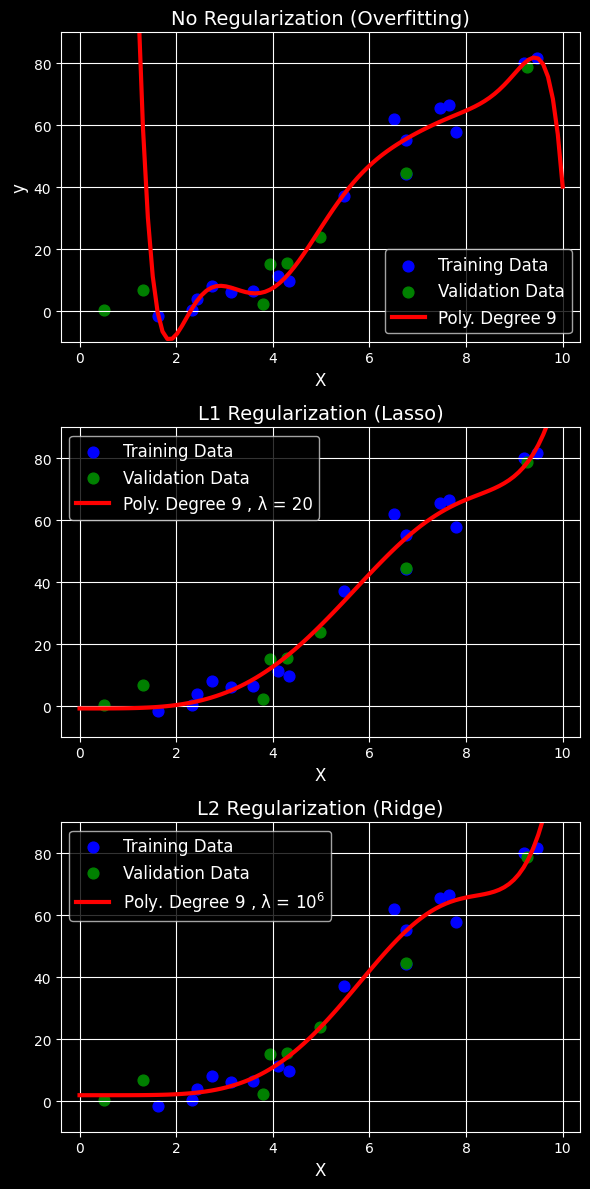

In [10]:
# --- Plotting ---
fig, axes = plt.subplots(3, 1, figsize=(6, 12), sharey=True)
models = [
    (y_pred_no_reg, "No Regularization (Overfitting)", ""),
    (y_pred_l1, "L1 Regularization (Lasso)", ", λ = 20"),
    (y_pred_l2, "L2 Regularization (Ridge)", ", λ = $10^6$"),
]

x_min, x_max = X.min(), X.max()
y_min, y_max = y.min(), y.max()
x_padding = (x_max - x_min) * 0.1
y_padding = (y_max - y_min) * 0.1

for i, (y_pred, title, alpha_val) in enumerate(models):
    ax = axes[i]
    ax.scatter(X_train, y_train, color="blue", s=60, label="Training Data")
    ax.scatter(X_val, y_val, color="green", s=60, label="Validation Data")
    ax.plot(
        X_plot,
        y_pred,
        color="red",
        linewidth=3,
        label=f"Poly. Degree {degree} {alpha_val}",
    )
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("X", fontsize=12)
    if i == 0:
        ax.set_ylabel("y", fontsize=12)
    ax.set_xlim(x_min - x_padding, x_max + x_padding)
    ax.set_ylim(y_min - y_padding, y_max + y_padding)
    ax.legend(fontsize=12)
    ax.grid(True)

plt.tight_layout()
plt.show()

In [11]:
# Print coefficients for all models
print("\n--- No Regularization Model Coefficients (First 10) ---")
print(np.round(model_no_reg.intercept_, 4))
print(np.round(model_no_reg.coef_[:10], 4))

print("\n--- L1 Regularization Model Coefficients (First 10) ---")
print(np.round(model_l1.intercept_, 4))
print(np.round(model_l1.coef_[:10], 4))
print(f"Number of non-zero coefficients: {np.sum(model_l1.coef_ != 0)}")

print("\n--- L2 Regularization Model Coefficients (First 10) ---")
print(np.round(model_l2.intercept_, 4))
print(np.round(model_l2.coef_[:10], 4))


# output----------------------------------------------------------
# MSE on validation (no regulization):  165943.76790632805
# MSE on validation (L1 regulization):  28.590165067988043
# MSE on validation (L2 regulization):  25.598355453809567


--- No Regularization Model Coefficients (First 10) ---
3902.0997
[ 0.0000000e+00 -8.4287606e+03  7.5978496e+03 -3.7719790e+03
  1.1436665e+03 -2.2098620e+02  2.7380900e+01 -2.1092000e+00
  9.2100000e-02 -1.7000000e-03]

--- L1 Regularization Model Coefficients (First 10) ---
-0.7719
[ 0.     -0.     -0.      0.      0.081  -0.0049 -0.0005 -0.      0.
  0.    ]
Number of non-zero coefficients: 6

--- L2 Regularization Model Coefficients (First 10) ---
1.8927
[ 0.      0.      0.      0.0002  0.0009  0.003   0.0057 -0.0015  0.0001
 -0.    ]
